# World Models for Process Systems: Part 1 — Synthetic Data Generation

World Models are a powerful class of deep learning architectures designed to learn an internal representation (a **latent space**) of an environment's dynamics. While heavily popularized in Reinforcement Learning and computer vision (e.g., World Models by Ha & Schmidhuber, JEPA by LeCun), they are equally applicable to **complex chemical and industrial process engineering**.

In industrial applications, we rarely have access to the true, unobserved state of a system. Instead, we rely on indirect, noisy, and non-linear sensor measurements.

### Objective of this Notebook
Before applying latent World Models (like VAEs or JEPAs), we construct a synthetic **Two-Tank Benchmark Problem**.
Since we define the underlying Ordinary Differential Equations (ODEs) ourselves, we know the **exact ground-truth latent state** $z_{\text{true}} = [h_1, h_2]^T$. This allows us to later benchmark how accurately our unsupervised World Model reconstructs the physical reality from raw sensor data alone.

In [2]:
import numpy as np
import scipy.integrate as spi
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import CCA
from sklearn.metrics import r2_score

# Set seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## 1. Physical System & ODE Formulation

We model two liquid storage tanks connected in series. Fluid is pumped into **Tank 1** with a controllable volume flow $u(t)$. Fluid drains out of Tank 1 directly into **Tank 2**, and subsequently discharges out of Tank 2 via free gravity flow.

Applying Torricelli's Law for non-linear orifice flow ($\propto \sqrt{h}$), the mass balance yields the following system of non-linear ODEs:

$$
\frac{d h_1}{dt} = \frac{1}{A_1} \left(u(t) - k_1 \sqrt{h_1}\right)
$$

$$
\frac{d h_2}{dt} = \frac{1}{A_2} \left( k_1 \sqrt{h_1} - k_2 \sqrt{h_2} \right)
$$

Where:
- $h_1(t), h_2(t)$ are the fluid levels in meters (**Ground-Truth Latent State**: $z_{\text{true}} = [h_1, h_2]^T$).
- $u(t)$ is the pump volume flow rate in $\text{m}^3/\text{s}$ (**Control Action**).
- $A_1, A_2$ are the cross-sectional areas of the tanks ($\text{m}^2$).
- $k_1, k_2$ are the discharge valve flow coefficients ($\text{m}^{2.5}/\text{s}$).

In [3]:
# System Parameters
A1, A2 = 2.0, 1.5      # Cross-sectional tank areas (m^2)
k1, k2 = 0.5, 0.4      # Valve discharge coefficients
g = 9.81               # Gravity acceleration (m/s^2)
rho = 1000.0           # Fluid density (kg/m^3)

def two_tank_ode(t, z, u_func):
    """
    Ordinary Differential Equation (ODE) governing the two-tank process.
    z[0] = h1 (liquid height in Tank 1)
    z[1] = h2 (liquid height in Tank 2)
    """
    h1, h2 = z
    # Physical boundary constraint: heights cannot drop below zero
    h1 = max(h1, 0.0)
    h2 = max(h2, 0.0)

    u = u_func(t) # Current control action (pump flow)

    # Torricelli mass balance equations
    dh1_dt = (u - k1 * np.sqrt(h1)) / A1
    dh2_dt = (k1 * np.sqrt(h1) - k2 * np.sqrt(h2)) / A2

    return [dh1_dt, dh2_dt]

## 2. System Excitation & Numerical Integration

To excite the non-linear dynamics across a wide operating range, we drive the pump with a **randomized step-input sequence** $u(t)$. The pump holds a constant flow rate for 30-second intervals before stepping to a new random value.

We integrate the differential equations numerically using the standard **Runge-Kutta 4th/5th order method (RK45)** via `scipy.integrate.solve_ivp`.

In [4]:
# Simulation parameters
t_max = 1000.0   # Total simulation time in seconds
dt = 0.5         # Sampling time step in seconds
num_steps = int(t_max / dt)
t_eval = np.linspace(0, t_max, num_steps)

# Generate random step input sequence u(t) for system identification
step_duration = 30.0  # Change pump rate every 30 seconds
steps_per_change = int(step_duration / dt)
num_changes = int(np.ceil(num_steps / steps_per_change))

u_values = np.random.uniform(0.1, 1.2, size=num_changes)
u_signal = np.repeat(u_values, steps_per_change)[:num_steps]

# Interpolation function for the numerical solver
def u_func(t):
    idx = min(int(t / dt), len(u_signal) - 1)
    return u_signal[idx]

# Initial conditions: h1(0) = 0.5m, h2(0) = 0.2m
z0 = [0.5, 0.2]

# Integrate ODEs
sol = spi.solve_ivp(
    fun=two_tank_ode,
    t_span=(0, t_max),
    y0=z0,
    t_eval=t_eval,
    args=(u_func,),
    method='RK45'
)

# Extract ground-truth latent trajectories z_true: Shape (N, 2)
z_true = sol.y.T

## 3. Generating Synthetic Noisy Observations ($x_t$)

In real industrial facilities, we rarely measure $h_1$ and $h_2$ directly without noise or cross-sensitivity. To mimic real-world plant conditions, we construct a 4-dimensional observation vector $x_t \in \mathbb{R}^4$ with injected Gaussian measurement noise:

1. **Hydrostatic Bottom Pressure Tank 1 ($p_1$):** $p_1 = \rho \cdot g \cdot h_1 + \eta_1 \quad [\text{Pa}]$
2. **Total System Fluid Volume ($v_{\text{tot}}$):** $v_{\text{tot}} = A_1 \cdot h_1 + A_2 \cdot h_2 + \eta_2 \quad [\text{m}^3]$
3. **Non-Linear Logarithmic Level Sensor Tank 2 ($s_3$):** $s_3 = \ln(h_2 + 10^{-3}) + \eta_3$
4. **Hydrostatic Bottom Pressure Tank 2 ($p_2$):** $p_2 = \rho \cdot g \cdot h_2 + \eta_4 \quad [\text{Pa}]$

In [5]:
# Generate synthetic noisy sensor measurements x_t
p1 = rho * g * z_true[:, 0] + np.random.normal(0, 450, size=num_steps)
v_tot = A1 * z_true[:, 0] + A2 * z_true[:, 1] + np.random.normal(0, 0.5, size=num_steps)
s3 = np.log(np.maximum(z_true[:, 1], 1e-4)) + np.random.normal(0, 0.2, size=num_steps)
p2 = rho * g * z_true[:, 1] + np.random.normal(0, 500, size=num_steps)

# Stack into observation matrix x_obs: Shape (N, 4)
x_obs = np.column_stack([p1, v_tot, s3, p2])

print(f"Simulation successfully completed!")
print(f"Observation matrix shape (x_obs): {x_obs.shape}")
print(f"Ground truth state shape (z_true): {z_true.shape}")
print(f"Control input signal shape (u_signal): {u_signal.shape}")

Simulation successfully completed!
Observation matrix shape (x_obs): (2000, 4)
Ground truth state shape (z_true): (2000, 2)
Control input signal shape (u_signal): (2000,)


## 4. Visualizing Process Dynamics and Sensor Readings

Let's plot the generated dataset to inspect the ground-truth state trajectories $z_{\text{true}}$, the control input sequence $u(t)$, and the raw, noisy sensor observations $x_t$.

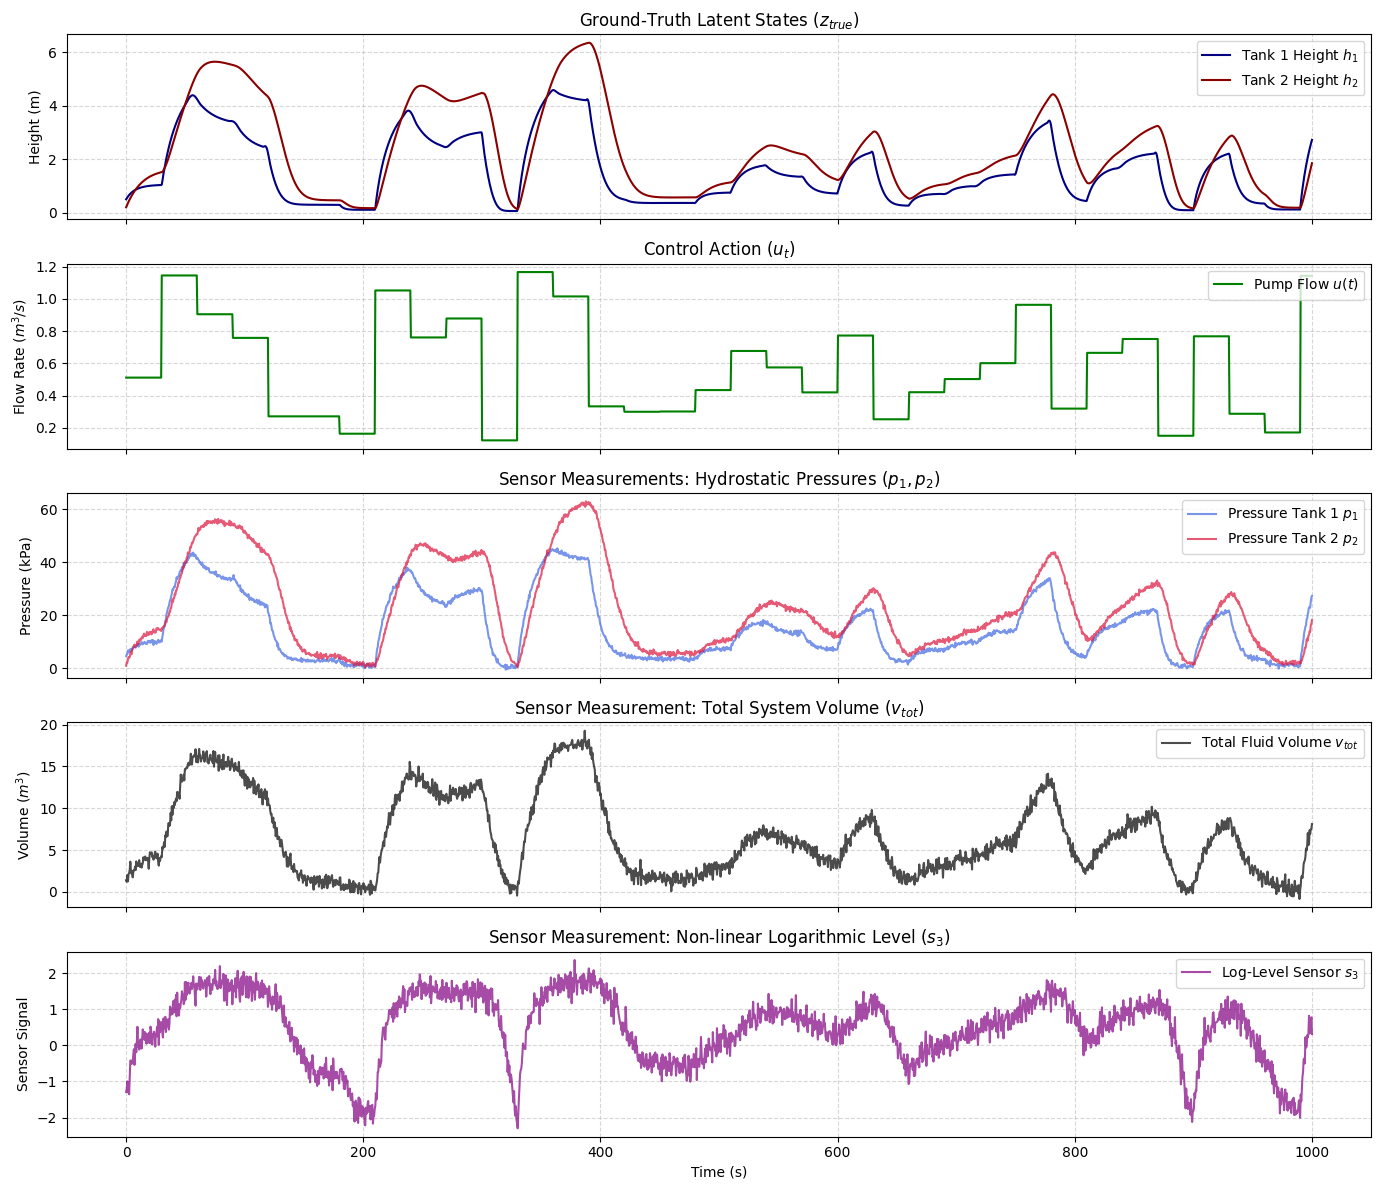

In [6]:
fig, axs = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

# Panel 1: Ground-Truth Heights z_true
axs[0].plot(t_eval, z_true[:, 0], label='Tank 1 Height $h_1$', color='navy', linewidth=1.5)
axs[0].plot(t_eval, z_true[:, 1], label='Tank 2 Height $h_2$', color='darkred', linewidth=1.5)
axs[0].set_ylabel('Height (m)')
axs[0].set_title('Ground-Truth Latent States ($z_{true}$)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend(loc='upper right')

# Panel 2: Control Input u(t)
axs[1].plot(t_eval, u_signal, label='Pump Flow $u(t)$', color='green', linewidth=1.5)
axs[1].set_ylabel('Flow Rate ($m^3/s$)')
axs[1].set_title('Control Action ($u_t$)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend(loc='upper right')

# Panel 3: Hydrostatic Pressures p1, p2
axs[2].plot(t_eval, x_obs[:, 0] / 1000, label='Pressure Tank 1 $p_1$', color='royalblue', alpha=0.7)
axs[2].plot(t_eval, x_obs[:, 3] / 1000, label='Pressure Tank 2 $p_2$', color='crimson', alpha=0.7)
axs[2].set_ylabel('Pressure (kPa)')
axs[2].set_title('Sensor Measurements: Hydrostatic Pressures ($p_1, p_2$)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend(loc='upper right')

# Panel 4: Total Volume v_tot
axs[3].plot(t_eval, x_obs[:, 1], label='Total Fluid Volume $v_{tot}$', color='black', alpha=0.7)
axs[3].set_ylabel('Volume ($m^3$)')
axs[3].set_title('Sensor Measurement: Total System Volume ($v_{tot}$)')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend(loc='upper right')

# Panel 5: Non-linear Sensor s3
axs[4].plot(t_eval, x_obs[:, 2], label='Log-Level Sensor $s_3$', color='purple', alpha=0.7)
axs[4].set_xlabel('Time (s)')
axs[4].set_ylabel('Sensor Signal')
axs[4].set_title('Sensor Measurement: Non-linear Logarithmic Level ($s_3$)')
axs[4].grid(True, linestyle='--', alpha=0.5)
axs[4].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 5. Data Preprocessing & History Window Construction (Frame Stacking)

Single-point sensor readings $x_t \in \mathbb{R}^4$ at a single time step carry noise and lack temporal derivative information ($\dot{x}_t$). To enable the neural network to infer time derivatives and smooth out high-frequency sensor noise, we employ **Frame Stacking / History Windows** based on **Takens' Embedding Theorem**.

Instead of feeding raw $x_t$, we stack $k=3$ consecutive time steps into a single history vector:

$$
\mathbf{x}_t^{\text{stacked}} = \big[ x_{t-2}, x_{t-1}, x_t \big] \in \mathbb{R}^{12}
$$

1. **Z-Score Normalization:** First, we standardize all sensor readings to zero mean and unit variance for stable neural network optimization.
2. **Lagged Dataset Creation:** We construct state-action-next_state triplets $(\mathbf{x}_t^{\text{stacked}}, u_t, \mathbf{x}_{t+1}^{\text{stacked}})$ for training.

In [7]:
# 1. Z-Score Normalization of raw sensor observations
x_mean = x_obs.mean(axis=0)
x_std = x_obs.std(axis=0) + 1e-8
x_obs_norm = (x_obs - x_mean) / x_std

# 2. Function to create a lagged dataset (History Window / Frame Stacking)
def create_lagged_dataset(x_obs_norm, u_signal, z_true, k=3):
    """
    Stacks k consecutive time steps into a single input vector.
    Input dimension increases from x_dim to x_dim * k.
    """
    N, x_dim = x_obs_norm.shape
    x_stacked = []

    for i in range(k - 1, N):
        window = x_obs_norm[i - k + 1 : i + 1].flatten()
        x_stacked.append(window)

    x_stacked = np.array(x_stacked)

    # Convert to PyTorch tensors and align time horizons
    x_t_stack = torch.tensor(x_stacked[:-1], dtype=torch.float32)
    u_t_stack = torch.tensor(u_signal[k-1:-1], dtype=torch.float32).unsqueeze(-1)
    x_next_stack = torch.tensor(x_stacked[1:], dtype=torch.float32)
    z_gt_stack = torch.tensor(z_true[k-1:-1], dtype=torch.float32)

    return x_t_stack, u_t_stack, x_next_stack, z_gt_stack

# Create dataset with k=3 history lags
k_lags = 3
x_t_s, u_t_s, x_next_s, z_gt_s = create_lagged_dataset(x_obs_norm, u_signal, z_true, k=k_lags)

# Create PyTorch TensorDataset and DataLoader
dataset = torch.utils.data.TensorDataset(x_t_s, u_t_s, x_next_s, z_gt_s)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

print(f"Dataset successfully created with k={k_lags} history lags.")
print(f"Stacked input dimension: {x_t_s.shape[1]} (4 sensors * {k_lags} time steps)")
print(f"Total dataset samples: {len(dataset)}")
print(f"DataLoader ready: {len(dataloader)} batches with batch size 64.")

Dataset successfully created with k=3 history lags.
Stacked input dimension: 12 (4 sensors * 3 time steps)
Total dataset samples: 1997
DataLoader ready: 32 batches with batch size 64.


## 6. Latent VAE World Model Architecture

The classical Latent Variational Autoencoder (VAE) World Model maps high-dimensional, noisy observations into a compact, continuous latent space $z_t \in \mathbb{R}^2$ and models the forward dynamics entirely within this learned space.

### Model Components
1. **Encoder $E_{\theta}(\mathbf{x}_t)$:** Maps stacked sensor observations $\mathbf{x}_t \in \mathbb{R}^{12}$ to the parameters of a Gaussian distribution: mean $\mu_t$ and log-variance $\log \sigma_t^2$ of the 2D latent state $z_t \in \mathbb{R}^2$.
2. **Decoder $D_{\phi}(z_t)$:** Reconstructs the high-dimensional observation $\hat{\mathbf{x}}_t$ from the latent vector $z_t$.
3. **Transition Predictor $T_{\psi}(z_t, u_t)$:** Predicts the next latent state $\hat{z}_{t+1}$ given the current latent state $z_t$ and control action $u_t$. For continuous physical ODE systems, we employ **residual learning** (Euler step):
   $$
   \hat{z}_{t+1} = z_t + \Delta z_t, \quad \text{where } \Delta z_t = T_{\psi}(z_t, u_t)
   $$

---

### Multi-Task Loss Formulation
The entire model is trained end-to-end by minimizing a composite objective function:

$$
\mathcal{L} = \mathcal{L}_{\text{Recon}} + \beta \cdot \mathcal{L}_{\text{KL}} + \gamma \cdot \mathcal{L}_{\text{Trans}}
$$

- **Reconstruction Loss ($\mathcal{L}_{\text{Recon}}$):** Mean Squared Error (MSE) between predicted observations $\hat{\mathbf{x}}_t, \hat{\mathbf{x}}_{t+1}$ and ground-truth observations $\mathbf{x}_t, \mathbf{x}_{t+1}$.
- **Kullback-Leibler Divergence ($\mathcal{L}_{\text{KL}}$):** Regularizes the latent distribution toward a standard normal prior $\mathcal{N}(0, I)$ to prevent sparse/overfitted representations.
- **Latent Transition Loss ($\mathcal{L}_{\text{Trans}}$):** Ensures that the transition network's forward prediction $\hat{z}_{t+1}$ matches the encoded next state $z_{t+1}$.

In [8]:
class VAEWorldModel(nn.Module):
    def __init__(self, x_dim=12, u_dim=1, z_dim=2, hidden_dim=64):
        super().__init__()

        # Encoder Network: x_t -> (mu, logvar)
        self.encoder = nn.Sequential(
            nn.Linear(x_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )
        self.fc_mu = nn.Linear(hidden_dim, z_dim)
        self.fc_logvar = nn.Linear(hidden_dim, z_dim)

        # Decoder Network: z_t -> x_hat_t
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, x_dim)
        )

        # Transition Predictor Network: (z_t, u_t) -> Delta z_t
        self.transition = nn.Sequential(
            nn.Linear(z_dim + u_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, z_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        # Clamping log-variance for numerical stability against NaNs
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Reparameterization trick: z = mu + std * eps"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def predict_next_z(self, z, u):
        """Residual transition step in latent space (Euler step)"""
        zu = torch.cat([z, u], dim=-1)
        delta_z = self.transition(zu)
        return z + delta_z

    def forward(self, x_t, u_t, x_next):
        # Encode current and next observation steps
        mu_t, logvar_t = self.encode(x_t)
        z_t = self.reparameterize(mu_t, logvar_t)

        mu_next, logvar_next = self.encode(x_next)
        z_next = self.reparameterize(mu_next, logvar_next)

        # Reconstruct observations
        x_t_hat = self.decoder(z_t)
        x_next_hat = self.decoder(z_next)

        # Predict next latent state
        z_next_pred = self.predict_next_z(z_t, u_t)

        return x_t_hat, x_next_hat, z_t, z_next, z_next_pred, mu_t, logvar_t

## 7. Model Training & Optimization

We train the VAE World Model end-to-end using the **Adam optimizer** with a learning rate of $\alpha = 10^{-3}$.

### Hyperparameters & Stabilization Tricks:
- **$\beta = 10^{-4}$ (KL Weight):** A gentle KL divergence weight prevents posterior collapse during early training steps.
- **$\gamma = 1.0$ (Transition Weight):** Ensures strong coupling between the current latent state $z_t$ and the predicted next state $\hat{z}_{t+1}$.
- **Gradient Clipping (`max_norm=1.0`):** Prevents exploding gradients when computing residual step updates in the transition network.

In [9]:
# Instantiate model with stacked input dimension (4 sensors * 3 lags = 12)
model = VAEWorldModel(x_dim=4 * k_lags, u_dim=1, z_dim=2, hidden_dim=64)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 80
beta = 1e-4   # KL divergence weight
gamma = 1.0   # Transition loss weight

loss_history = []

model.train()
print("Training VAE World Model...")
for epoch in range(1, epochs + 1):
    total_loss = 0.0
    for b_xt, b_ut, b_xnext, _ in dataloader:
        optimizer.zero_grad()

        # Forward pass
        x_t_hat, x_next_hat, z_t, z_next, z_next_pred, mu_t, logvar_t = model(b_xt, b_ut, b_xnext)

        # Loss computation
        loss_recon = nn.functional.mse_loss(x_t_hat, b_xt) + nn.functional.mse_loss(x_next_hat, b_xnext)
        loss_kl = -0.5 * torch.mean(1 + logvar_t - mu_t.pow(2) - logvar_t.exp())
        loss_trans = nn.functional.mse_loss(z_next_pred, z_next.detach())

        loss = loss_recon + beta * loss_kl + gamma * loss_trans
        loss.backward()

        # Gradient clipping for training stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{epochs} | Loss: {avg_loss:.5f}")

Training VAE World Model...
Epoch 01/80 | Loss: 2.48452
Epoch 20/80 | Loss: 0.03436
Epoch 40/80 | Loss: 0.02994
Epoch 60/80 | Loss: 0.02981
Epoch 80/80 | Loss: 0.03045


## 8. Evaluating Latent Space Alignment: Linear Probing

Because the VAE World Model is trained **completely unsupervised** (without ever seeing the true physical heights $h_1, h_2$), the learned 2D latent space $z_{\text{learned}} \in \mathbb{R}^2$ does not natively share the same coordinate axes as $z_{\text{true}}$.

In unsupervised representation learning, the learned latent space is subject to **linear transformation invariances** (rotation, scaling, shear, and offset).

### Linear Probing
To quantify whether $z_{\text{learned}}$ captures the underlying physical state space, we perform **Linear Probing**:
1. Encode all sensor observations into the latent representation $z_{\text{learned}} = \mu_t$.
2. Fit a linear regression model: $W \cdot z_{\text{learned}} + b \approx z_{\text{true}}$.
3. Compute the coefficient of determination ($R^2$-Score).

> **Key Insight:** A high $R^2$-Score ($> 0.95$) proves that the unsupervised VAE successfully extracted the **true physical degrees of freedom** ($h_1$ and $h_2$) from noisy sensor signals without human labels!

In [10]:
model.eval()
with torch.no_grad():
    # Pass all stacked observations through the encoder to extract mean latent states
    all_lagged_x = torch.cat([x_t_s, x_next_s[-1:]], dim=0)
    mu_all, _ = model.encode(all_lagged_x)
    z_learned = mu_all.numpy()

# Trim z_true to align with history lags (k_lags - 1 steps lost at start)
z_true_trimmed = z_true[k_lags - 1:]

# Fit Linear Probing Model (z_learned -> z_true)
reg = LinearRegression().fit(z_learned, z_true_trimmed)
r2_score = reg.score(z_learned, z_true_trimmed)

# Map latent representation back to physical dimensions (m)
z_reconstructed = reg.predict(z_learned)

print("\n" + "="*55)
print(f" Linear Probing R² Score (z_learned -> z_true): {r2_score:.4f}")
print("="*55)


 Linear Probing R² Score (z_learned -> z_true): 0.9786


## 9. Visualizing Reconstructed Tank Levels

We now overlay the physical ground-truth tank heights $h_1(t)$ and $h_2(t)$ with the values reconstructed from our unsupervised VAE World Model.

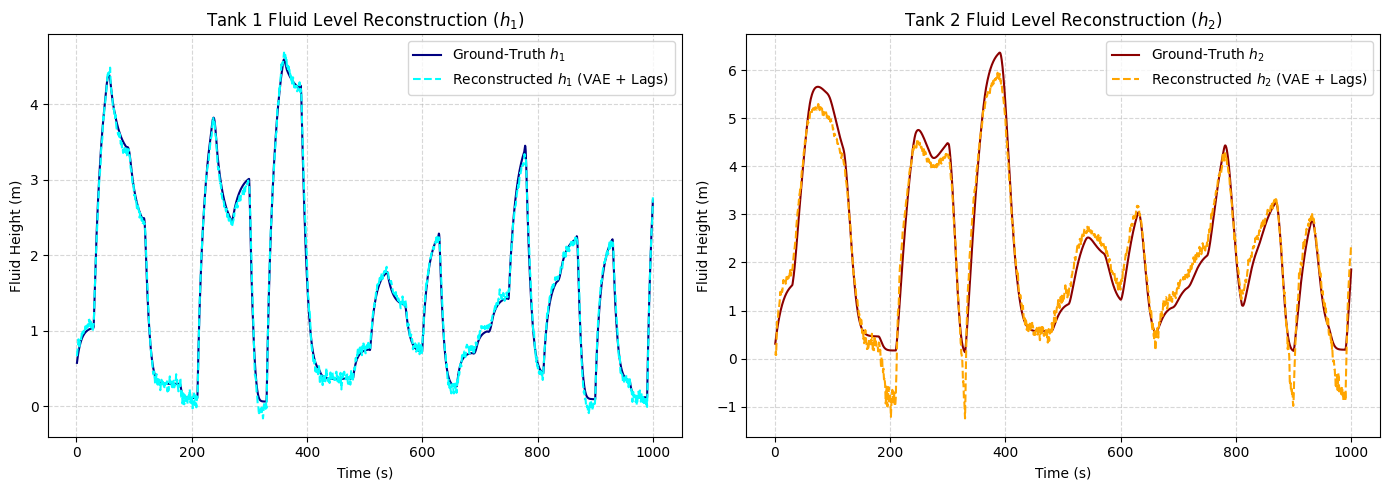

In [11]:
t_eval_trimmed = t_eval[k_lags - 1:]

plt.figure(figsize=(14, 5))

# Subplot 1: Tank 1 Level (h1)
plt.subplot(1, 2, 1)
plt.plot(t_eval_trimmed, z_true_trimmed[:, 0], label='Ground-Truth $h_1$', color='navy', linewidth=1.5)
plt.plot(t_eval_trimmed, z_reconstructed[:, 0], label=f'Reconstructed $h_1$ (VAE + Lags)', color='cyan', linestyle='--', linewidth=1.5)
plt.title('Tank 1 Fluid Level Reconstruction ($h_1$)')
plt.xlabel('Time (s)')
plt.ylabel('Fluid Height (m)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# Subplot 2: Tank 2 Level (h2)
plt.subplot(1, 2, 2)
plt.plot(t_eval_trimmed, z_true_trimmed[:, 1], label='Ground-Truth $h_2$', color='darkred', linewidth=1.5)
plt.plot(t_eval_trimmed, z_reconstructed[:, 1], label=f'Reconstructed $h_2$ (VAE + Lags)', color='orange', linestyle='--', linewidth=1.5)
plt.title('Tank 2 Fluid Level Reconstruction ($h_2$)')
plt.xlabel('Time (s)')
plt.ylabel('Fluid Height (m)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 10. Deep Latent Space Analysis: CKA, CCA & Phase Portraits

Standard $R^2$-scores from linear regression evaluate linear alignment, but they don't fully capture whether the **topological manifold** of the process was preserved. Because VAEs are subject to rotation, scaling, and axis-mixing (entanglement), we apply three advanced evaluation methods:

### 1. Centered Kernel Alignment (CKA)
CKA measures the structural similarity between two representation matrices without requiring coordinate alignment. A CKA score close to **1.0** ($> 0.90$) confirms that state distances in the physical phase space are strictly proportional to state distances in the learned latent space.

### 2. Phase Space Topology
By plotting $h_1$ vs. $h_2$ against $z_1$ vs. $z_2$ and coloring the trajectories by time step $t$, we can visually verify if the learned latent space preserves the exact geometric loops and manifold shape of the dynamical system.

### 3. Feature Disentanglement vs. Entanglement
- **Ideal Disentangled Representation:** A diagonal correlation matrix ($\approx 1.0$ on diagonals, $0.0$ off-diagonals) means $z_1$ exclusively encodes $h_1$, and $z_2$ exclusively encodes $h_2$.
- **Typical Entangled VAE Representation:** Unsupervised VAEs often learn a rotated principal component axis (e.g., $z_1 \approx h_1 + h_2$ and $z_2 \approx h_1 - h_2$). While feature dimensions are entangled, the full system dynamics are still perfectly preserved.

 QUANTITATIVE LATENT SPACE COMPARISON METRICS
• CKA Similarity Score:           0.9324  (1.0 = perfect manifold isomorphism)
• CCA Correlation Dimension 1:   0.9985
• CCA Correlation Dimension 2:   0.9227


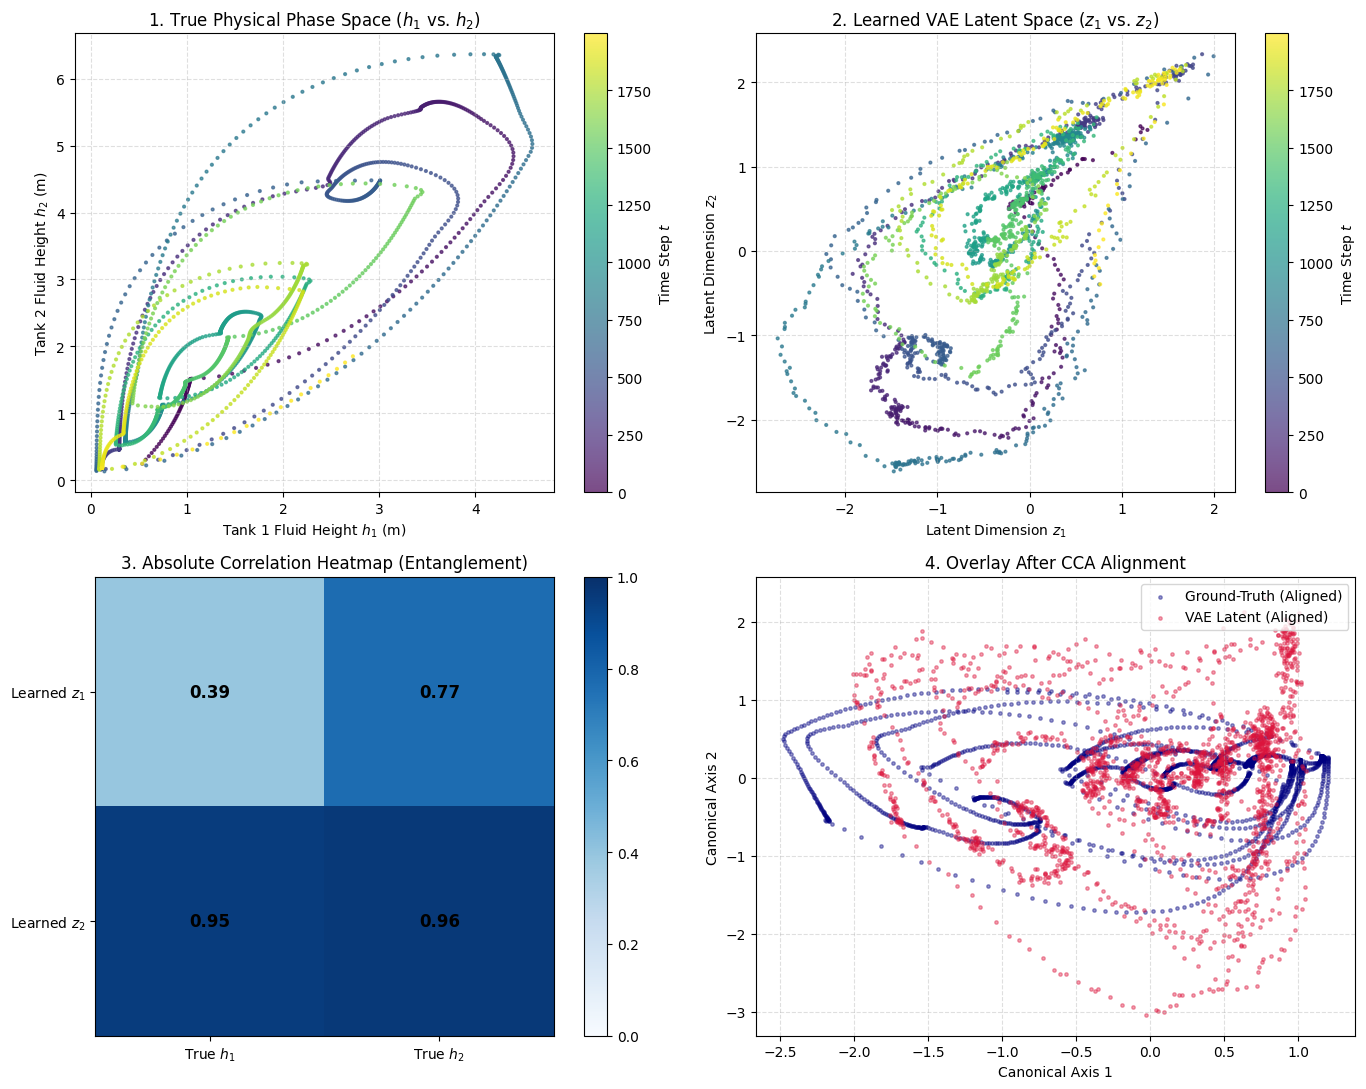

In [12]:
# Align z_true to match the length of z_learned (lost k_lags - 1 steps due to history window)
z_true_trimmed = z_true[k_lags - 1:]

# ==========================================
# 1. QUANTITATIVE METRICS (CCA & CKA)
# ==========================================

# A) Canonical Correlation Analysis (CCA)
# Finds optimal linear projections to maximize correlation between latent spaces
cca = CCA(n_components=2)
z_l_c, z_t_c = cca.fit_transform(z_learned, z_true_trimmed)

corr_dim1 = np.corrcoef(z_l_c[:, 0], z_t_c[:, 0])[0, 1]
corr_dim2 = np.corrcoef(z_l_c[:, 1], z_t_c[:, 1])[0, 1]

# B) Linear Centered Kernel Alignment (CKA)
def linear_cka(X, Y):
    """Computes Linear CKA similarity between representation matrices X and Y."""
    X_c = X - X.mean(axis=0)
    Y_c = Y - Y.mean(axis=0)

    hsic = np.linalg.norm(X_c.T @ Y_c, 'fro')**2
    var_x = np.linalg.norm(X_c.T @ X_c, 'fro')
    var_y = np.linalg.norm(Y_c.T @ Y_c, 'fro')

    return hsic / (var_x * var_y + 1e-12)

cka_score = linear_cka(z_learned, z_true_trimmed)

print("="*55)
print(" QUANTITATIVE LATENT SPACE COMPARISON METRICS")
print("="*55)
print(f"• CKA Similarity Score:           {cka_score:.4f}  (1.0 = perfect manifold isomorphism)")
print(f"• CCA Correlation Dimension 1:   {corr_dim1:.4f}")
print(f"• CCA Correlation Dimension 2:   {corr_dim2:.4f}")
print("="*55)

# ==========================================
# 2. VISUAL ANALYSIS (4 PANEL PLOTS)
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(14, 11))

# Plot 1: True Phase Space (h1 vs h2)
sc1 = axs[0, 0].scatter(z_true_trimmed[:, 0], z_true_trimmed[:, 1], c=np.arange(len(z_true_trimmed)), cmap='viridis', s=4, alpha=0.7)
axs[0, 0].set_title("1. True Physical Phase Space ($h_1$ vs. $h_2$)")
axs[0, 0].set_xlabel("Tank 1 Fluid Height $h_1$ (m)")
axs[0, 0].set_ylabel("Tank 2 Fluid Height $h_2$ (m)")
axs[0, 0].grid(True, linestyle='--', alpha=0.4)
fig.colorbar(sc1, ax=axs[0, 0], label="Time Step $t$")

# Plot 2: Learned VAE Latent Space (z1 vs z2)
sc2 = axs[0, 1].scatter(z_learned[:, 0], z_learned[:, 1], c=np.arange(len(z_learned)), cmap='viridis', s=4, alpha=0.7)
axs[0, 1].set_title("2. Learned VAE Latent Space ($z_1$ vs. $z_2$)")
axs[0, 1].set_xlabel("Latent Dimension $z_1$")
axs[0, 1].set_ylabel("Latent Dimension $z_2$")
axs[0, 1].grid(True, linestyle='--', alpha=0.4)
fig.colorbar(sc2, ax=axs[0, 1], label="Time Step $t$")

# Plot 3: Absolute Correlation Heatmap (Entanglement Check)
corr_matrix = np.abs(np.corrcoef(z_learned.T, z_true_trimmed.T)[:2, 2:])
im = axs[1, 0].imshow(corr_matrix, cmap='Blues', vmin=0, vmax=1)
axs[1, 0].set_xticks([0, 1])
axs[1, 0].set_xticklabels(['True $h_1$', 'True $h_2$'])
axs[1, 0].set_yticks([0, 1])
axs[1, 0].set_yticklabels(['Learned $z_1$', 'Learned $z_2$'])
axs[1, 0].set_title("3. Absolute Correlation Heatmap (Entanglement)")

for i in range(2):
    for j in range(2):
        axs[1, 0].text(j, i, f"{corr_matrix[i, j]:.2f}", ha="center", va="center", color="black", fontsize=12, fontweight='bold')
fig.colorbar(im, ax=axs[1, 0])

# Plot 4: CCA-Aligned Latent Overlay
axs[1, 1].scatter(z_t_c[:, 0], z_t_c[:, 1], label='Ground-Truth (Aligned)', color='navy', alpha=0.4, s=6)
axs[1, 1].scatter(z_l_c[:, 0], z_l_c[:, 1], label='VAE Latent (Aligned)', color='crimson', alpha=0.4, s=6)
axs[1, 1].set_title("4. Overlay After CCA Alignment")
axs[1, 1].set_xlabel("Canonical Axis 1")
axs[1, 1].set_ylabel("Canonical Axis 2")
axs[1, 1].grid(True, linestyle='--', alpha=0.4)
axs[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 11. One-Step Sensor Prediction in Physical Measurement Space

A key capability of a World Model is predicting future sensor measurements without executing actual physical experiments.

To evaluate the predictive decoder performance:
1. We pass the current stacked observation $\mathbf{x}_t$ through the encoder to obtain $z_t$.
2. The transition network predicts the next latent state: $\hat{z}_{t+1} = z_t + T_\psi(z_t, u_t)$.
3. We decode the predicted latent state back into observation space: $\hat{\mathbf{x}}_{t+1} = D_\phi(\hat{z}_{t+1})$.
4. Finally, we **denormalize** $\hat{\mathbf{x}}_{t+1}$ back to physical units ($\text{kPa}$, $\text{m}^3$, log units) and compare the predicted sensor signals directly with the noisy ground-truth measurements.

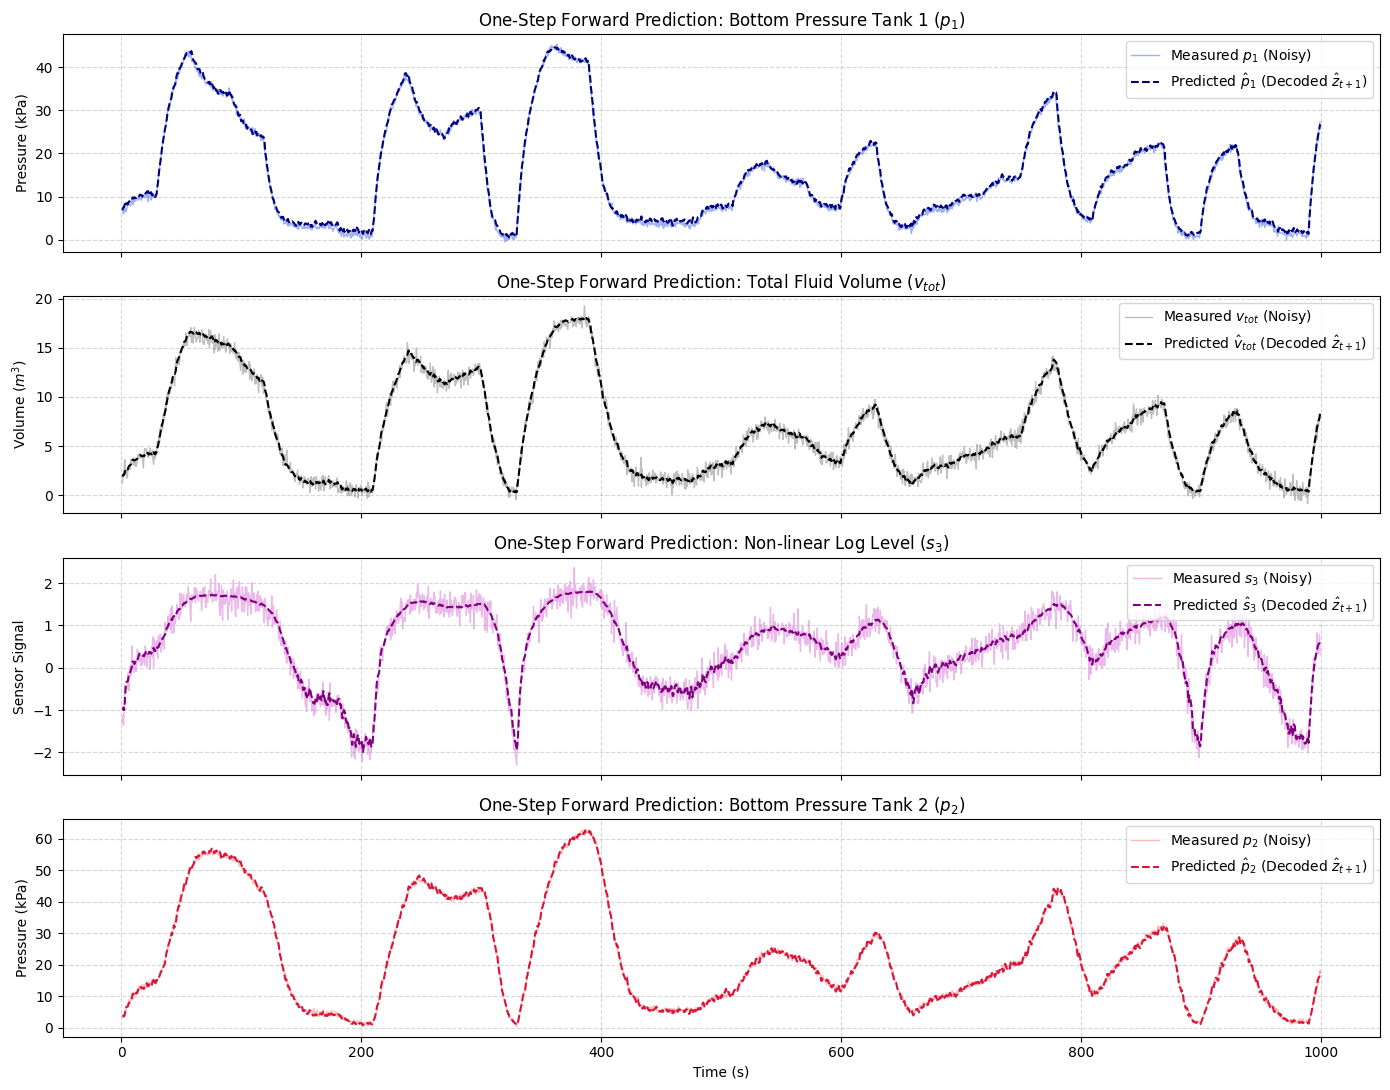

In [13]:
model.eval()
with torch.no_grad():
    # 1. Encode current observations x_t
    mu_t, _ = model.encode(x_t_s)

    # 2. Predict next latent state z_{t+1} using the transition network
    z_next_pred = model.predict_next_z(mu_t, u_t_s)

    # 3. Decode predicted latent state back into normalized sensor space (12D stacked)
    x_next_pred_stacked = model.decoder(z_next_pred).numpy()

# Extract the most recent 4 sensor channels (last 4 elements of the 12D stacked vector)
x_next_pred_norm = x_next_pred_stacked[:, -4:]
x_next_true_norm = x_next_s.numpy()[:, -4:]

# Denormalize back to physical sensor units
x_next_pred_phys = (x_next_pred_norm * x_std) + x_mean
x_next_true_phys = (x_next_true_norm * x_std) + x_mean

t_eval_trimmed = t_eval[k_lags - 1:-1]

# ==========================================
# VISUALIZE SENSOR PREDICTIONS VS MEASUREMENTS
# ==========================================
fig, axs = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

# Panel 1: Hydrostatic Pressure Tank 1 (p1)
axs[0].plot(t_eval_trimmed, x_next_true_phys[:, 0] / 1000, label=r'Measured $p_1$ (Noisy)', color='royalblue', alpha=0.5, linewidth=1)
axs[0].plot(t_eval_trimmed, x_next_pred_phys[:, 0] / 1000, label=r'Predicted $\hat{p}_1$ (Decoded $\hat{z}_{t+1}$)', color='navy', linestyle='--', linewidth=1.5)
axs[0].set_ylabel(r'Pressure (kPa)')
axs[0].set_title(r'One-Step Forward Prediction: Bottom Pressure Tank 1 ($p_1$)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend(loc='upper right')

# Panel 2: Total System Volume (v_tot)
axs[1].plot(t_eval_trimmed, x_next_true_phys[:, 1], label=r'Measured $v_{tot}$ (Noisy)', color='gray', alpha=0.5, linewidth=1)
axs[1].plot(t_eval_trimmed, x_next_pred_phys[:, 1], label=r'Predicted $\hat{v}_{tot}$ (Decoded $\hat{z}_{t+1}$)', color='black', linestyle='--', linewidth=1.5)
axs[1].set_ylabel(r'Volume ($m^3$)')
axs[1].set_title(r'One-Step Forward Prediction: Total Fluid Volume ($v_{tot}$)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend(loc='upper right')

# Panel 3: Non-linear Sensor Tank 2 (s3)
axs[2].plot(t_eval_trimmed, x_next_true_phys[:, 2], label=r'Measured $s_3$ (Noisy)', color='orchid', alpha=0.5, linewidth=1)
axs[2].plot(t_eval_trimmed, x_next_pred_phys[:, 2], label=r'Predicted $\hat{s}_3$ (Decoded $\hat{z}_{t+1}$)', color='purple', linestyle='--', linewidth=1.5)
axs[2].set_ylabel(r'Sensor Signal')
axs[2].set_title(r'One-Step Forward Prediction: Non-linear Log Level ($s_3$)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend(loc='upper right')

# Panel 4: Hydrostatic Pressure Tank 2 (p2)
axs[3].plot(t_eval_trimmed, x_next_true_phys[:, 3] / 1000, label=r'Measured $p_2$ (Noisy)', color='salmon', alpha=0.5, linewidth=1)
axs[3].plot(t_eval_trimmed, x_next_pred_phys[:, 3] / 1000, label=r'Predicted $\hat{p}_2$ (Decoded $\hat{z}_{t+1}$)', color='crimson', linestyle='--', linewidth=1.5)
axs[3].set_xlabel(r'Time (s)')
axs[3].set_ylabel(r'Pressure (kPa)')
axs[3].set_title(r'One-Step Forward Prediction: Bottom Pressure Tank 2 ($p_2$)')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 12. Discussion: Why are Predicted Sensor Signals Smoother than Raw Measurements?

Looking at the predicted sensor signals $\hat{\mathbf{x}}_{t+1}$, an important observation emerges: **the model's predictions are significantly less noisy than the ground-truth sensor measurements**.

This denoising capability stems from three fundamental Machine Learning principles:

1. **Dimensionality Bottleneck:** The input space consists of 12 dimensions ($4 \text{ sensors} \times 3 \text{ history lags}$), whereas the latent space $z_t$ is strictly 2-dimensional. Because Gaussian measurement noise has high entropy and no correlation across time, the network cannot compress it into the 2D latent space. It automatically discards noise as uncompressible information.
2. **MSE Loss & Expected Value:** Minimizing the Mean Squared Error (MSE) causes the neural network to approximate the **conditional expectation** $\mathbb{E}[\mathbf{x}_t | z_t]$. Since zero-mean Gaussian measurement noise has an expected value of zero ($\mathbb{E}[\eta] = 0$), the decoder predicts the underlying "clean" physical state.
3. **Implicit Kalman Filtering:** Combined with our 3-step history window (Frame Stacking), the encoder acts as an implicit temporal low-pass filter, recovering the true system dynamics without explicit noise filtering algorithms.